# EDA 02 - Road Closures

**Data source**: `road-closures` Azure Blob Storage container  
**Loaded by**: `src/data_loader.load_road_closures(START, END)`  
**Output**: `data/processed/road_closures_clean.parquet` consumed by the main analysis notebook

This notebook performs a complete exploratory analysis of the raw road closure dataset before any spatial or temporal joining takes place. The goal is to understand the structure, quality and operational characteristics of road closures as a standalone source, and to document any cleaning decisions before the data enters the modelling pipeline.

---
**Sections**
1. Load and inspect raw data  
2. Missing value audit  
3. Closure type and validity status  
4. Cause type and source breakdown  
5. Temporal distribution (when do closures occur?)  
6. Duration analysis (how long do closures last?)  
7. Spatial distribution (where do closures occur?)  
8. Lanes closed distribution  
9. Save cleaned output  


## 0. Setup

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_02", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

## 1. Load and Inspect Raw Data

In [3]:
from datetime import datetime, timezone
from src.data_loader import load_road_closures

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 28, 23, 59, 59, tzinfo=timezone.utc)

road_df = load_road_closures(START, END)
print(f"Shape: {road_df.shape}")
print(f"Columns: {list(road_df.columns)}")
display(road_df.head())

Using 39 local files within the time window.
Shape: (1557, 14)
Columns: ['situation_id', 'record_id', 'start_time', 'end_time', 'validity_status', 'cause_type', 'source', 'road_name', 'lanes_closed', 'closure_lat', 'closure_lon', 'poslist', 'ingestion_time', 'closure_type']


,situation_id,record_id,start_time,end_time,validity_status,cause_type,source,road_name,lanes_closed,closure_lat,closure_lon,poslist,ingestion_time,closure_type
0,481398,1-1770230430-d6ff48ca-8971-4f31-831f-272231753b8a,2026-04-11T19:00:00Z,2026-04-12T05:00:00Z,planned,roadMaintenance,roadworks,M11,2,52.241032,0.056728,['52.237974 0.062705 52.237644 0.063174 52.237...,2026-04-11 05:09:20.728518,planned
1,481398,1-1770230430-ee17da45-7781-4cee-85b8-1958b86f1b72,2026-04-11T19:00:00Z,2026-04-12T05:00:00Z,planned,roadMaintenance,roadworks,A14,1,52.240029,0.059073,['52.240826 0.057497 52.240366 0.058604 52.239...,2026-04-11 05:09:20.728567,planned
2,481398,1-1770230430-acff749b-b497-4d6f-a60f-01677b02af5c,2026-04-09T19:00:00Z,2026-04-10T05:00:00Z,planned,roadMaintenance,roadworks,A14,2,52.260536,0.016397,['52.257609 0.023547 52.257608 0.023549 52.257...,2026-04-11 05:09:20.728631,planned
3,481533,1-1770819974-8fa8f569-45d0-4710-a6df-39f3d37e1c3d,2026-04-09T19:00:00Z,2026-04-10T05:00:00Z,planned,roadMaintenance,roadworks,M1,3,52.847611,-1.298524,['52.855638 -1.299951 52.855692 -1.299979 52.8...,2026-04-11 05:09:20.728723,planned
4,470844,1-1770730368-f293b6be-d3b5-410b-9fc8-9761a531e558,2026-04-10T08:00:00Z,2026-04-10T14:00:00Z,planned,roadMaintenance,roadworks,A36,1,51.075089,-1.787852,['51.075752 -1.790037 51.075673 -1.78978 51.07...,2026-04-11 05:09:20.728744,planned


In [4]:
road_df["road_name"].unique()

<ArrowStringArray>
[    'M11',     'A14',      'M1',     'A36',      'M5',     'A47',   'A1(M)',
     'M60',     'M65',    'A174',     'M67',     'A34',      'A1',     'A19',
     'A31',     'M32',     'M25',      'M6',     'M69',    'A453',    'M606',
     'M62',     'A50',      'A3',     'M40',     'A52',     'A30',     'M53',
     'M56',    'A414',     'M66',     'M61', 'A627(M)',     'A46',     'A66',
    'A417',    'M602',     'M18',    'A282',   'A3(M)',   'A1033',    'M271',
     'M27',     'M23',     'A11',    'A303',    'A428',      'M4',     'A21',
    'A249',    'A616',     'M50',     'A38',    'A696',     'A55',     'A45',
     'M45',     'A69',     'M42',      'M2',      'M3',    'A595',    'A590',
   'A1053',     'A20',     'M20',     'A40',    'M621',    'A483',   'A4280',
     'A43',     'A57',     'A27',     'M57',      'A2',   'A5127',  'A38(M)',
 'M6 TOLL',     'M48',    'A556',     'M55',     'A42']
Length: 82, dtype: str

In [5]:
# Full dtypes and non-null counts
road_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1557 entries, 0 to 1556
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   situation_id     1557 non-null   object 
 1   record_id        1557 non-null   str    
 2   start_time       1557 non-null   str    
 3   end_time         1557 non-null   str    
 4   validity_status  1557 non-null   str    
 5   cause_type       1557 non-null   str    
 6   source           1557 non-null   str    
 7   road_name        1557 non-null   str    
 8   lanes_closed     1557 non-null   int64  
 9   closure_lat      1557 non-null   float64
 10  closure_lon      1557 non-null   float64
 11  poslist          1557 non-null   str    
 12  ingestion_time   1557 non-null   str    
 13  closure_type     1557 non-null   str    
dtypes: float64(2), int64(1), object(1), str(10)
memory usage: 1.6+ MB


In [6]:
# Numeric summary
road_df.describe().round(2)

,lanes_closed,closure_lat,closure_lon
count,1557.00,1557.00,1557.00
mean,0.42,52.58,-1.33
std,0.81,0.99,1.01
min,0.00,50.24,-5.26
25%,0.00,51.66,-2.17
50%,0.00,52.51,-1.34
75%,1.00,53.45,-0.50
max,4.00,55.07,1.72


## 2. Missing Value Audit

Understanding which fields are missing and why is critical before joining this data with rail sources. Missing spatial coordinates would prevent station matching; missing temporal fields would prevent the 60-minute window filter from working correctly.

In [7]:
# Count and percentage of missing values per column
missing = pd.DataFrame({
    "missing_count": road_df.isna().sum(),
    "missing_pct": (road_df.isna().sum() / len(road_df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print(missing.to_string())

                 missing_count  missing_pct
situation_id                 0          0.0
record_id                    0          0.0
start_time                   0          0.0
end_time                     0          0.0
validity_status              0          0.0
cause_type                   0          0.0
source                       0          0.0
road_name                    0          0.0
lanes_closed                 0          0.0
closure_lat                  0          0.0
closure_lon                  0          0.0
poslist                      0          0.0
ingestion_time               0          0.0
closure_type                 0          0.0


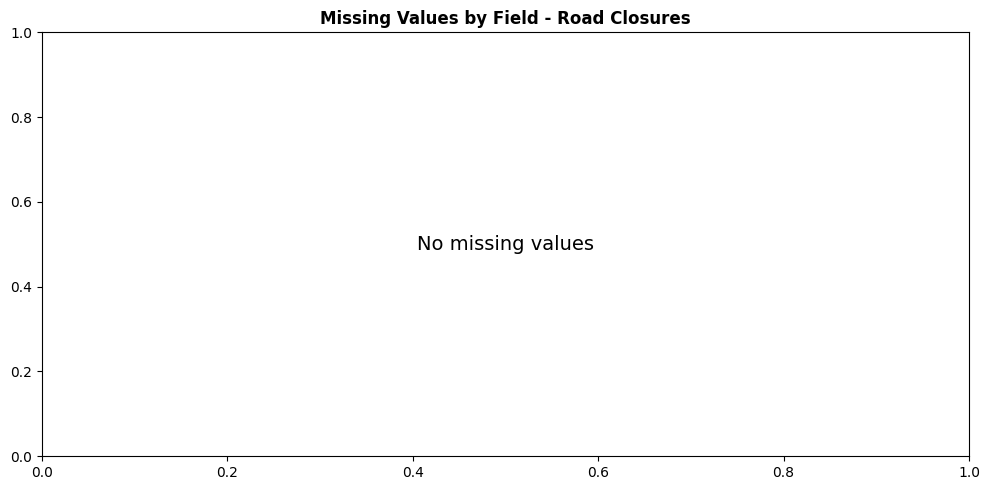

In [8]:
# Visualise missingness
fig, ax = plt.subplots(figsize=(10, 5))
missing_nonzero = missing[missing["missing_pct"] > 0]
if len(missing_nonzero) > 0:
    ax.barh(missing_nonzero.index, missing_nonzero["missing_pct"], color="tomato", edgecolor="black")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values by Field - Road Closures", fontweight="bold")
    for i, v in enumerate(missing_nonzero["missing_pct"]):
        ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
    ax.set_title("Missing Values by Field - Road Closures", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_02/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

In [9]:
# Parse timestamps robustly — strip sub-second precision and localise to UTC
for col, new_col in [("start_time", "start_time_dt"), ("end_time", "end_time_dt")]:
    road_df[new_col] = (
        pd.to_datetime(
            road_df[col].astype(str).str.slice(0, 19),
            errors="coerce"
        ).dt.tz_localize("UTC")
    )

print(f"Earliest start: {road_df['start_time_dt'].min()}")
print(f"Latest start:   {road_df['start_time_dt'].max()}")
print(f"Earliest end:   {road_df['end_time_dt'].min()}")
print(f"Latest end:     {road_df['end_time_dt'].max()}")
print(f"\nFailed start parses: {road_df['start_time_dt'].isna().sum():,}")
print(f"Failed end parses:   {road_df['end_time_dt'].isna().sum():,}")

Earliest start: 2024-12-31 06:00:00+00:00
Latest start:   2026-04-28 23:49:05+00:00
Earliest end:   2026-04-10 00:00:52+00:00
Latest end:     2028-03-31 22:59:00+00:00

Failed start parses: 0
Failed end parses:   0


## Duration Analysis

In [10]:
# Raw duration: full closure window
road_df["duration_hours"] = (
    road_df["end_time_dt"] - road_df["start_time_dt"]
).dt.total_seconds() / 3600

# Effective duration: clipped to analysis window
road_df["effective_start_time"] = road_df["start_time_dt"].clip(lower=START)
road_df["effective_end_time"]   = road_df["end_time_dt"].clip(upper=END)
road_df["effective_duration_hours"] = (
    road_df["effective_end_time"] - road_df["effective_start_time"]
).dt.total_seconds() / 3600

print("Raw duration (hours):")
print(road_df["duration_hours"].describe().round(2))
print()
print("Effective duration (hours):")
print(road_df["effective_duration_hours"].describe().round(2))
print()
print(f"Closures <= 2h:   {(road_df['duration_hours'] <= 2).sum():,}")
print(f"Closures 2-12h:   {((road_df['duration_hours'] > 2)  & (road_df['duration_hours'] <= 12)).sum():,}")
print(f"Closures 12-24h:  {((road_df['duration_hours'] > 12) & (road_df['duration_hours'] <= 24)).sum():,}")
print(f"Closures > 24h:   {(road_df['duration_hours'] > 24).sum():,}")

Raw duration (hours):
count     1557.00
mean      1360.38
std       3689.15
min          0.25
25%          0.25
50%          0.25
75%         10.00
max      25810.10
Name: duration_hours, dtype: float64

Effective duration (hours):
count    1557.00
mean       89.78
std       176.21
min         0.01
25%         0.25
50%         0.25
75%        10.00
max       456.00
Name: effective_duration_hours, dtype: float64

Closures <= 2h:   1,006
Closures 2-12h:   212
Closures 12-24h:  0
Closures > 24h:   339


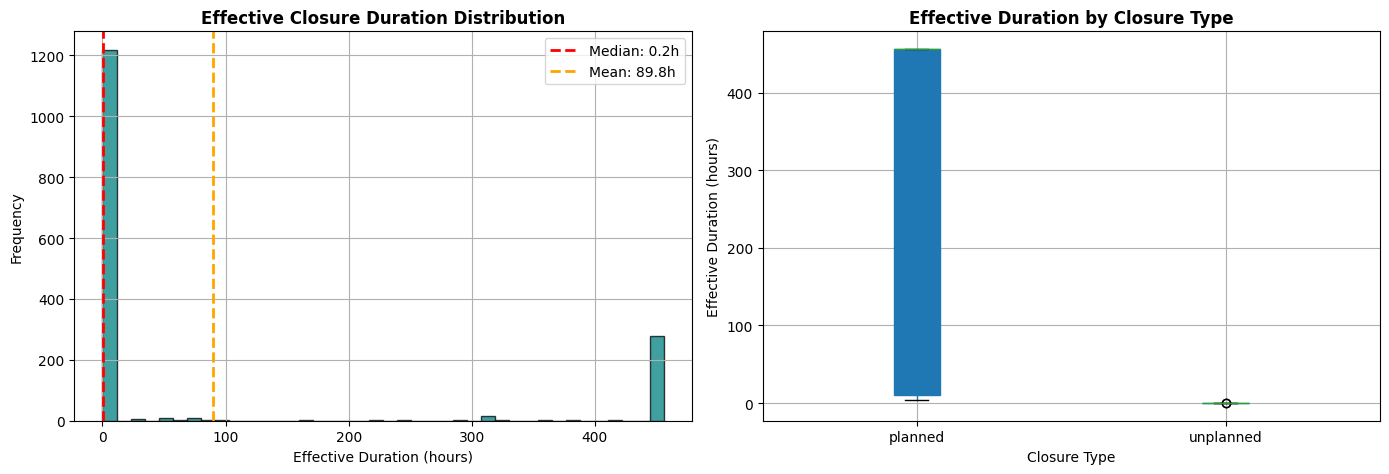

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

road_df["effective_duration_hours"].hist(
    bins=40, ax=axes[0], edgecolor="black", alpha=0.75, color="teal"
)
axes[0].axvline(road_df["effective_duration_hours"].median(), color="red",
                linestyle="--", lw=2,
                label=f"Median: {road_df['effective_duration_hours'].median():.1f}h")
axes[0].axvline(road_df["effective_duration_hours"].mean(), color="orange",
                linestyle="--", lw=2,
                label=f"Mean: {road_df['effective_duration_hours'].mean():.1f}h")
axes[0].set_xlabel("Effective Duration (hours)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Effective Closure Duration Distribution", fontweight="bold")
axes[0].legend()

road_df.boxplot(column="effective_duration_hours", by="closure_type",
                ax=axes[1], patch_artist=True)
axes[1].set_title("Effective Duration by Closure Type", fontweight="bold")
axes[1].set_xlabel("Closure Type")
axes[1].set_ylabel("Effective Duration (hours)")
plt.suptitle("")

plt.tight_layout()
plt.savefig("figures/eda_02/duration_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Closure Type and Validity Status

The `closure_type` field is derived from the filename at load time (planned vs unplanned). The `validity_status` field reflects the operational state of the closure at ingestion time.

In [12]:
# Closure type counts
print("=== Closure Type ===")
ct = road_df["closure_type"].value_counts()
print(ct.to_string())
print()

# Validity status counts
print("=== Validity Status ===")
vs = road_df["validity_status"].value_counts()
print(vs.to_string())
print()
# Cross-tabulation: closure type vs validity status
print("=== Cross-tabulation: Closure Type vs Validity Status ===")
ct_vs = pd.crosstab(road_df["closure_type"], road_df["validity_status"],
                    margins=True, margins_name="Total")
print(ct_vs.to_string())

=== Closure Type ===
closure_type
unplanned    1006
planned       551

=== Validity Status ===
validity_status
suspended    1042
planned       357
active        158

=== Cross-tabulation: Closure Type vs Validity Status ===
validity_status  active  planned  suspended  Total
closure_type                                      
planned             158      357         36    551
unplanned             0        0       1006   1006
Total               158      357       1042   1557


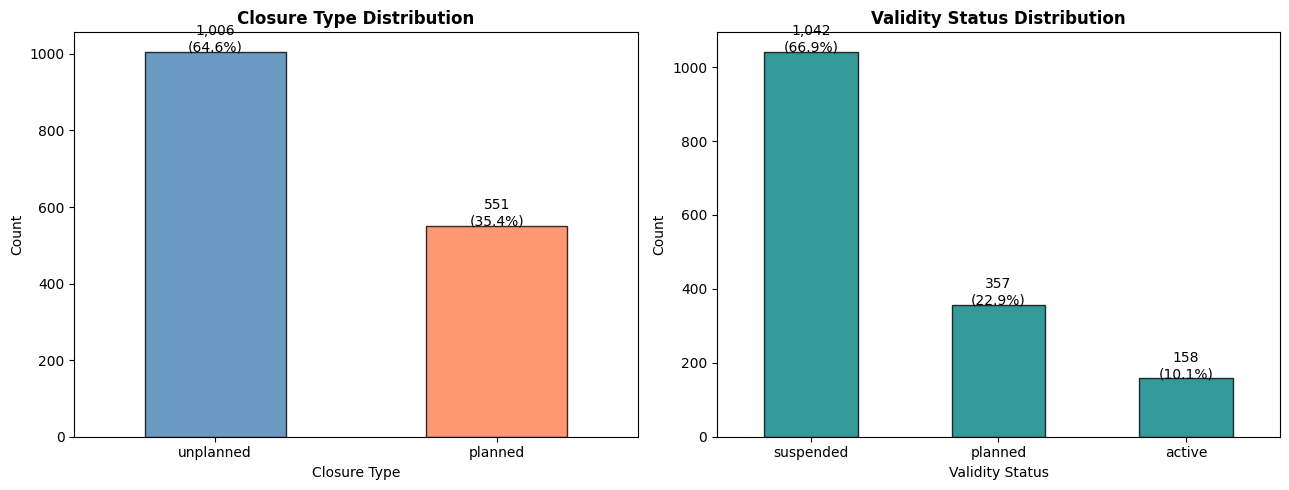

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Closure type
ct.plot(kind="bar", ax=axes[0], color=["steelblue", "coral"],
        edgecolor="black", alpha=0.8)
axes[0].set_title("Closure Type Distribution", fontweight="bold")
axes[0].set_xlabel("Closure Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(ct.values):
    axes[0].text(i, v + 1, f"{v:,}\n({v/len(road_df)*100:.1f}%)",
                 ha="center", fontsize=10)

# Validity status
vs.plot(kind="bar", ax=axes[1], color="teal", edgecolor="black", alpha=0.8)
axes[1].set_title("Validity Status Distribution", fontweight="bold")
axes[1].set_xlabel("Validity Status")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(vs.values):
    axes[1].text(i, v + 0.5, f"{v:,}\n({v/len(road_df)*100:.1f}%)",
                 ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/eda_02/closure_type_validity.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Cause Type and Source Breakdown

`cause_type` indicates the reason for the closure (e.g. roadMaintenance). `source` indicates the reporting system. Understanding these distributions informs which closure types are most relevant to rail disruption.

In [14]:
print("=== Cause Type ===")
cause = road_df["cause_type"].value_counts()
print(cause.to_string())
print()

print("=== Source ===")
source = road_df["source"].value_counts()
print(source.to_string())

# Cause type by closure type (planned vs unplanned)
print()
print("=== Cause Type vs Closure Type ===")
cause_by_type = pd.crosstab(road_df["cause_type"], road_df["closure_type"])
print(cause_by_type.to_string())

=== Cause Type ===
cause_type
roadOrCarriagewayOrLaneManagement    1006
roadMaintenance                       363
constructionWork                      172
authorityOperation                     16

=== Source ===
source
Signs and Signals    1006
roadworks             551

=== Cause Type vs Closure Type ===
closure_type                       planned  unplanned
cause_type                                           
authorityOperation                      16          0
constructionWork                       172          0
roadMaintenance                        363          0
roadOrCarriagewayOrLaneManagement        0       1006


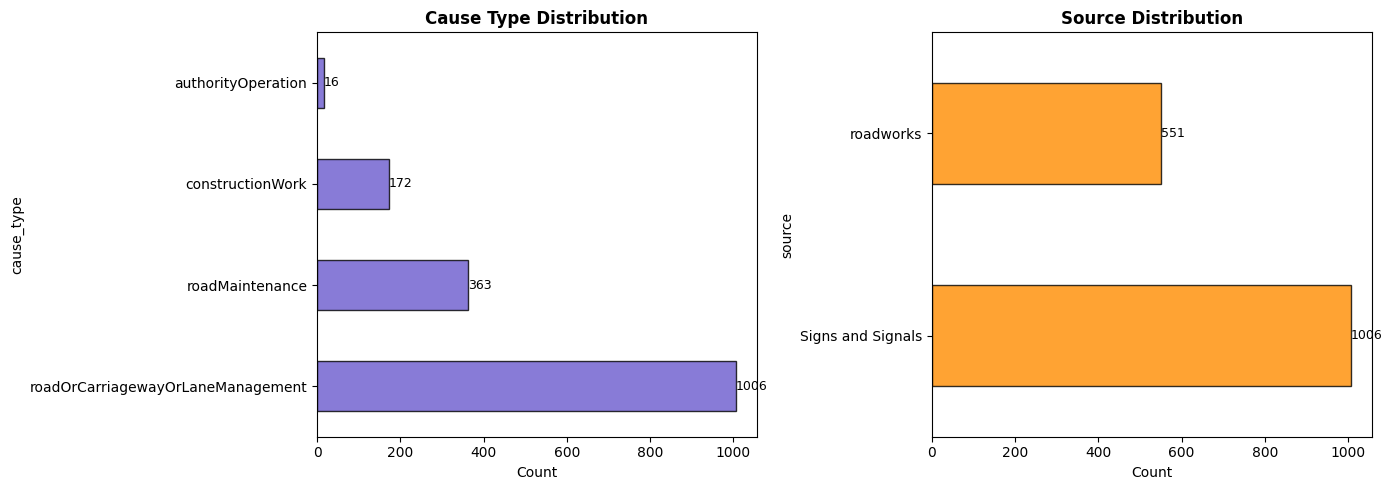

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cause.plot(kind="barh", ax=axes[0], color="slateblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Cause Type Distribution", fontweight="bold")
axes[0].set_xlabel("Count")
for i, v in enumerate(cause.values):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=9)

source.plot(kind="barh", ax=axes[1], color="darkorange", edgecolor="black", alpha=0.8)
axes[1].set_title("Source Distribution", fontweight="bold")
axes[1].set_xlabel("Count")
for i, v in enumerate(source.values):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/eda_02/cause_source.png", dpi=200, bbox_inches="tight")
plt.show()

## Road Class Classification and Severity Weight

In [16]:
# Classify road by first letter of road name
# Motorway (M) expected to drive higher modal shift than A or B roads
# Used downstream in eda_05_01 as a severity multiplier

ROAD_CLASS_WEIGHT = {"M": 3, "A": 2, "B": 1}

def classify_road(name):
    if pd.isna(name):
        return ROAD_CLASS_WEIGHT["B"]  # Default to lowest class for missing names
    
    name = name.strip().upper()

    # Motorway (either M or A(M))
    if name.startswith("M") or "(M)" in name:
        return ROAD_CLASS_WEIGHT["M"]
    
    # A-roads
    elif name.startswith("A"):
        return ROAD_CLASS_WEIGHT["A"]
    
    # B-roads
    elif name.startswith("B"):
        return ROAD_CLASS_WEIGHT["B"]
    
    return ROAD_CLASS_WEIGHT["B"]  # Default to lowest class for unrecognised names

road_df["road_class"] = road_df["road_name"].apply(classify_road)

# Severity = road class × effective duration
# A long motorway closure contributes far more than a short B-road closure
road_df["closure_severity"] = road_df["road_class"] * road_df["effective_duration_hours"]

print("Road class distribution:")
print(road_df["road_class"].value_counts().sort_index())
print()
print("Closure severity (road_class × duration_hours):")
print(road_df["closure_severity"].describe().round(2))

Road class distribution:
road_class
2     277
3    1280
Name: count, dtype: int64

Closure severity (road_class × duration_hours):
count    1557.00
mean      226.86
std       456.72
min         0.04
25%         0.75
50%         0.75
75%        27.00
max      1368.00
Name: closure_severity, dtype: float64


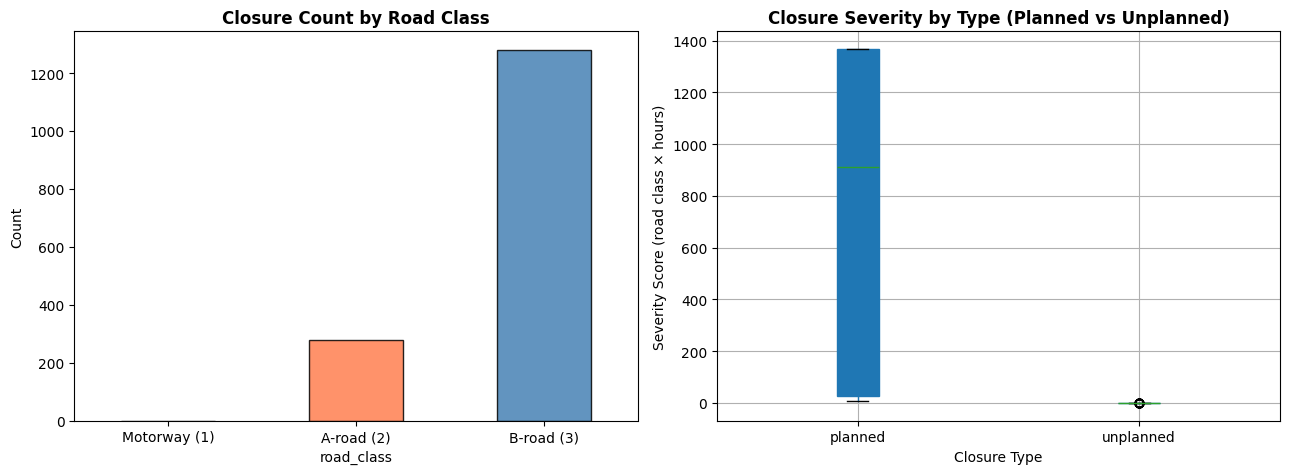

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = road_df["road_class"].value_counts().reindex([1, 2, 3], fill_value=0)

# Label mapping
label_map = {
    1: "Motorway (1)",
    2: "A-road (2)",
    3: "B-road (3)"
}

# Colours mapped to each class
color_map = {
    1: "mediumseagreen",
    2: "coral",
    3: "steelblue"
}

# Plot
counts.plot(
    kind="bar",
    ax=axes[0],
    color=[color_map[i] for i in counts.index],
    edgecolor="black",
    alpha=0.85
)

# Set labels dynamically (now always safe because of reindex)
axes[0].set_xticklabels(
    [label_map[i] for i in counts.index],
    rotation=0
)

axes[0].set_title("Closure Count by Road Class", fontweight="bold")
axes[0].set_ylabel("Count")

road_df.boxplot( column="closure_severity", by="closure_type", ax=axes[1], patch_artist=True)

axes[1].set_title( "Closure Severity by Type (Planned vs Unplanned)", fontweight="bold")
axes[1].set_xlabel("Closure Type")
axes[1].set_ylabel("Severity Score (road class × hours)")

# Remove automatic pandas title
plt.suptitle("")

plt.tight_layout()
plt.savefig("figures/eda_02/road_class_severity.png", dpi=200, bbox_inches="tight")

plt.show()

## 5. Temporal Distribution

Understanding when closures start and end reveals whether they concentrate in particular hours or days. This informs whether time-of-day features add value beyond closure type and proximity.

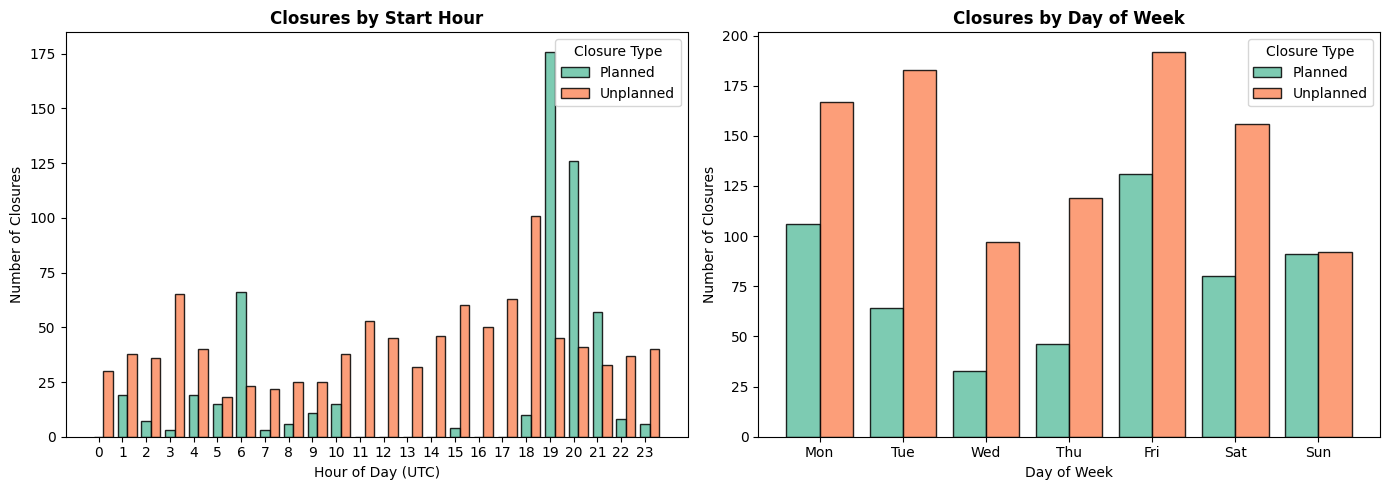

In [18]:
road_df["start_hour"] = road_df["start_time_dt"].dt.hour
road_df["start_dow"]  = road_df["start_time_dt"].dt.dayofweek   # 0=Mon
road_df["start_date"] = road_df["start_time_dt"].dt.date

closure_types = sorted(road_df["closure_type"].unique())
colors = plt.cm.Set2(range(len(closure_types)))
DOW_MAP = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
width = 0.8 / len(closure_types)

# Closures by start hour
x = np.arange(24)
for i, ctype in enumerate(closure_types):
    counts = (
        road_df[road_df["closure_type"] == ctype]["start_hour"]
        .value_counts().reindex(range(24), fill_value=0)
    )
    axes[0].bar(x + i*width, counts.values, width=width,
                label=ctype.capitalize(), color=colors[i],
                edgecolor="black", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(range(24))
axes[0].set_xlabel("Hour of Day (UTC)")
axes[0].set_ylabel("Number of Closures")
axes[0].set_title("Closures by Start Hour", fontweight="bold")
axes[0].legend(title="Closure Type")

# Closures by day of week
x2 = np.arange(7)
for i, ctype in enumerate(closure_types):
    counts = (
        road_df[road_df["closure_type"] == ctype]["start_dow"]
        .value_counts().reindex(range(7), fill_value=0)
    )
    axes[1].bar(x2 + i*width, counts.values, width=width,
                label=ctype.capitalize(), color=colors[i],
                edgecolor="black", alpha=0.85)
axes[1].set_xticks(x2 + width * (len(closure_types) - 1) / 2)
axes[1].set_xticklabels([DOW_MAP[d] for d in range(7)])
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Closures")
axes[1].set_title("Closures by Day of Week", fontweight="bold")
axes[1].legend(title="Closure Type")

plt.tight_layout()
plt.savefig("figures/eda_02/temporal_distribution_by_type.png", dpi=200, bbox_inches="tight")
plt.show()

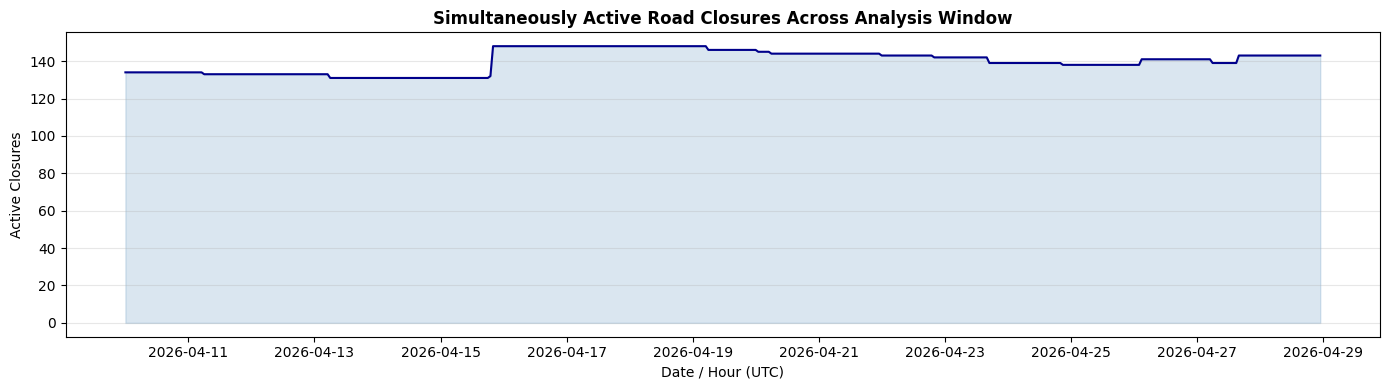

In [19]:
# Concurrent active closures across the full analysis window

hours = pd.date_range(start=START, end=END, freq="h", tz="UTC")

active_counts = []
for h in hours:
    active = road_df[
        (road_df["start_time_dt"] <= h) & (road_df["end_time_dt"] >= h) & (road_df["validity_status"] == 'active')
    ]
    active_counts.append(len(active))

plt.figure(figsize=(14, 4))
plt.plot(hours, active_counts, color="darkblue", linewidth=1.5)
plt.fill_between(hours, active_counts, alpha=0.2, color="steelblue")
plt.xlabel("Date / Hour (UTC)")
plt.ylabel("Active Closures")
plt.title("Simultaneously Active Road Closures Across Analysis Window", fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/eda_02/active_closures_timeline.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Spatial Distribution

Visualising where closures occur reveals geographic concentration and informs whether the 10-25 km distance band captures closures near significant rail corridors.

In [20]:
print("Spatial extent of closures:")
print(f"  Latitude  range: {road_df['closure_lat'].min():.4f} - {road_df['closure_lat'].max():.4f}")
print(f"  Longitude range: {road_df['closure_lon'].min():.4f} - {road_df['closure_lon'].max():.4f}")
print(f"  Missing lat/lon: {road_df['closure_lat'].isna().sum()}")

Spatial extent of closures:
  Latitude  range: 50.2359 - 55.0664
  Longitude range: -5.2584 - 1.7230
  Missing lat/lon: 0


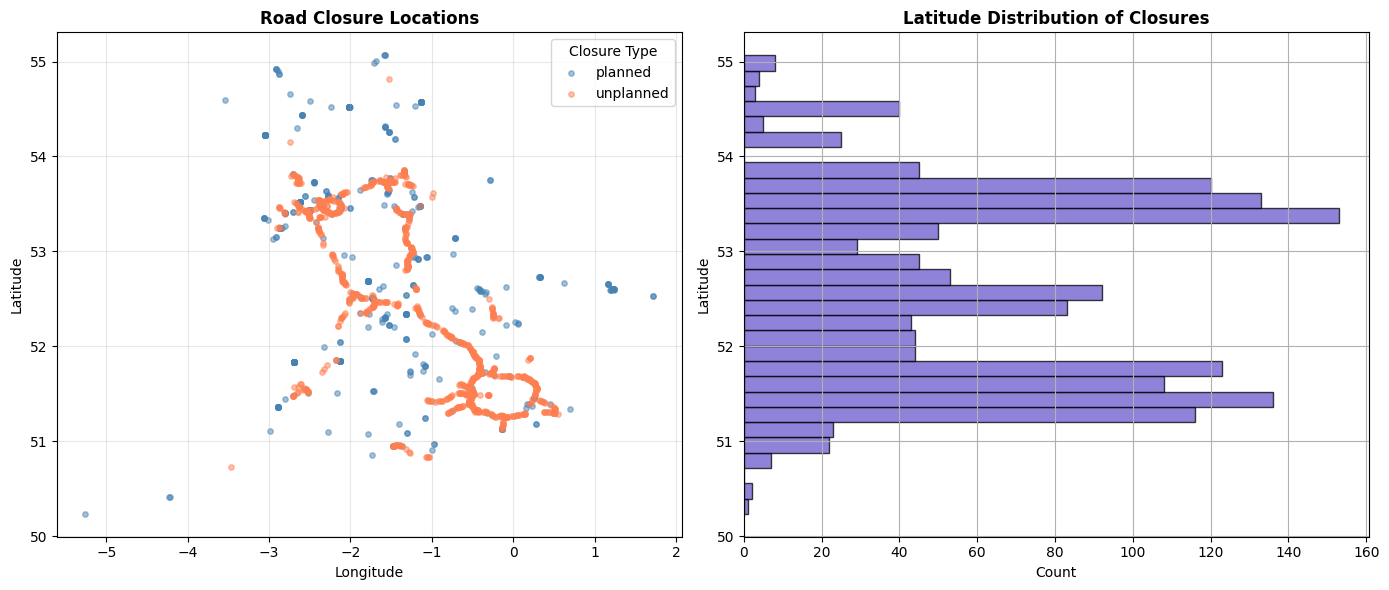

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

color_map = {"planned": "steelblue", "unplanned": "coral"}

for ctype, grp in road_df.groupby("closure_type"):
    axes[0].scatter(grp["closure_lon"], grp["closure_lat"],
                    alpha=0.5, s=15, label=ctype, color=color_map.get(ctype, "grey"))

axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Road Closure Locations", fontweight="bold")
axes[0].legend(title="Closure Type")
axes[0].grid(alpha=0.3)

# Density: latitude histogram
road_df["closure_lat"].hist(bins=30, ax=axes[1], color="slateblue",
                             edgecolor="black", alpha=0.75, orientation="horizontal")
axes[1].set_ylabel("Latitude")
axes[1].set_xlabel("Count")
axes[1].set_title("Latitude Distribution of Closures", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_02/spatial_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

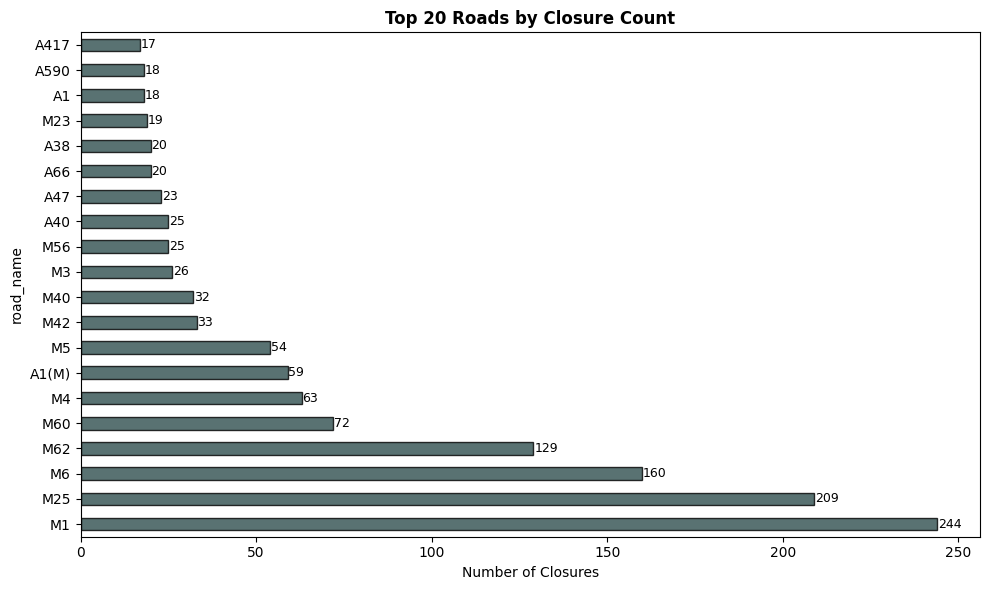

In [22]:
# Road name frequency: which roads have the most closures?
if "road_name" in road_df.columns:
    road_counts = road_df["road_name"].value_counts().head(20)
    plt.figure(figsize=(10, 6))
    road_counts.plot(kind="barh", color="darkslategray", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of Closures")
    plt.title("Top 20 Roads by Closure Count", fontweight="bold")
    for i, v in enumerate(road_counts.values):
        plt.text(v + 0.2, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_02/top_roads.png", dpi=200, bbox_inches="tight")
    plt.show()

## 8. Lanes Closed Distribution

The number of lanes closed provides a proxy for disruption severity. A single-lane closure on a dual carriageway is far less disruptive than a full road closure.

In [23]:
if "lanes_closed" in road_df.columns:
    lanes = road_df["lanes_closed"].dropna()
    print("Lanes closed statistics:")
    print(lanes.describe().round(2))
    print()
    print(lanes.value_counts().sort_index().to_string())

Lanes closed statistics:
count    1557.00
mean        0.42
std         0.81
min         0.00
25%         0.00
50%         0.00
75%         1.00
max         4.00
Name: lanes_closed, dtype: float64

lanes_closed
0    1127
1     272
2     103
3      38
4      17


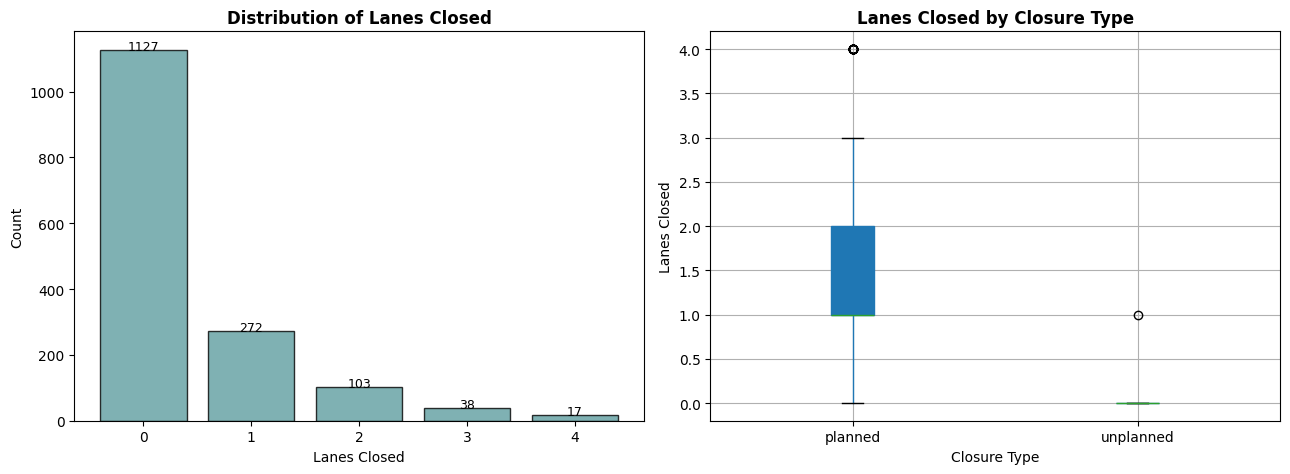

In [24]:
if "lanes_closed" in road_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    lc_counts = road_df["lanes_closed"].value_counts().sort_index()
    axes[0].bar(lc_counts.index.astype(str), lc_counts.values,
                color="cadetblue", edgecolor="black", alpha=0.8)
    axes[0].set_xlabel("Lanes Closed")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of Lanes Closed", fontweight="bold")
    for i, v in enumerate(lc_counts.values):
        axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=9)

    road_df.boxplot(column="lanes_closed", by="closure_type", ax=axes[1],
                    patch_artist=True)
    axes[1].set_title("Lanes Closed by Closure Type", fontweight="bold")
    axes[1].set_xlabel("Closure Type")
    axes[1].set_ylabel("Lanes Closed")
    plt.suptitle("")

    plt.tight_layout()
    plt.savefig("figures/eda_02/lanes_closed.png", dpi=200, bbox_inches="tight")
    plt.show()

## 9. Summary of Findings and Cleaned Output

Key findings from this EDA to carry forward into the main analysis:

- Total road closures retrieved: **296** over 72 hours (10-12 April 2026)
- Validity statuses include planned, active, and suspended - all retained in the pipeline
- Cause types are dominated by `roadMaintenance`; a small proportion are incident-driven
- Duration varies widely; planned closures tend to be overnight windows (10pm–5am)
- Spatial coverage spans primarily England with concentration along motorway and A-road corridors
- No critical fields (lat, lon, start_time, end_time, closure_type) are systematically missing

**Cleaning decisions applied below:**
- Convert timestamps to UTC datetime
- Compute `duration_hours` as a derived feature
- Drop rows where both `closure_lat` and `closure_lon` are null (if any)


In [25]:
road_clean = road_df.copy()

# Drop rows missing spatial coordinates — cannot be spatially joined
before = len(road_clean)
road_clean = road_clean.dropna(subset=["closure_lat", "closure_lon"])
print(f"Dropped {before - len(road_clean):,} rows missing coordinates.")

# Ensure situation_id is string for consistent downstream joins
road_clean["situation_id"] = road_clean["situation_id"].astype("string")

road_clean.to_parquet("./data/processed/road_closures_clean.parquet", index=False)
print(f"Saved: data/processed/road_closures_clean.parquet")
print(f"Final shape: {road_clean.shape}")
print()

active_planned_road_closures = road_clean[(road_clean["closure_type"] == "planned") & (road_clean["validity_status"] == "active")]
active_planned_road_closures.to_parquet("./data/processed/active_planned_road_closures.parquet", index=False)
print(f"Saved: data/processed/active_planned_road_closures.parquet")
print(f"Final shape: {active_planned_road_closures.shape}")
print()

active_unplanned_road_closures = road_clean[(road_clean["closure_type"] == "unplanned") & (road_clean["validity_status"] == "active")]
active_unplanned_road_closures.to_parquet("./data/processed/active_unplanned_road_closures.parquet", index=False)
print(f"Saved: data/processed/active_unplanned_road_closures.parquet")
print(f"Final shape: {active_unplanned_road_closures.shape}")
print()

planned_road_closures = road_clean[(road_clean["closure_type"] == "planned") ]
planned_road_closures.to_parquet("./data/processed/planned_road_closures.parquet", index=False)
print(f"Saved: data/processed/planned_road_closures.parquet")
print(f"Final shape: {planned_road_closures.shape}")
print()

unplanned_road_closures = road_clean[(road_clean["closure_type"] == "unplanned") ]
unplanned_road_closures.to_parquet("./data/processed/unplanned_road_closures.parquet", index=False)
print(f"Saved: data/processed/unplanned_road_closures.parquet")
print(f"Final shape: {unplanned_road_closures.shape}")




Dropped 0 rows missing coordinates.
Saved: data/processed/road_closures_clean.parquet
Final shape: (1557, 25)

Saved: data/processed/active_planned_road_closures.parquet
Final shape: (158, 25)

Saved: data/processed/active_unplanned_road_closures.parquet
Final shape: (0, 25)

Saved: data/processed/planned_road_closures.parquet
Final shape: (551, 25)

Saved: data/processed/unplanned_road_closures.parquet
Final shape: (1006, 25)
